# Visualising PCA
To see and visualise the results from PCA

Note that before running the functions/plots within this document, the preprocessing main tasks must be completed (see main_run_tasks.sh).

### SETUP

In [7]:
import sys, os, importlib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pca_main_functions
importlib.reload(pca_main_functions)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

base_dir=os.path.join(os.path.dirname(os.getcwd()), 'DOSCAR_files')

interpolated_filepath = os.path.join(base_dir,'interpolated_dos.txt')

# Check if the file exists
if not os.path.exists(interpolated_filepath):
    raise FileNotFoundError(f"The file {interpolated_filepath} does not exist. Please check the path.")

molecule_names, dos_data = pca_main_functions.load_interpolated_dos(interpolated_filepath)

energy_values = dos_data.iloc[0,:]
dos_samples = dos_data.iloc[1:,:]

pca, scaled_data = pca_main_functions.perform_PCA(dos_samples)
principal_components = pca.fit_transform(scaled_data)


c:\Users\jespe\Desktop\[THESIS] Code\-ESPEJO-THESIS-DOS-ML-Model-\SCRIPTS_PCA\pca_main_functions.py:21: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filepath, delim_whitespace=True, header=None)


PCA results saved at: c:\Users\jespe\Desktop\[THESIS] Code\-ESPEJO-THESIS-DOS-ML-Model-\SCRIPTS_PCA\pca_data.txt


### 1. Visualising the Principal Components

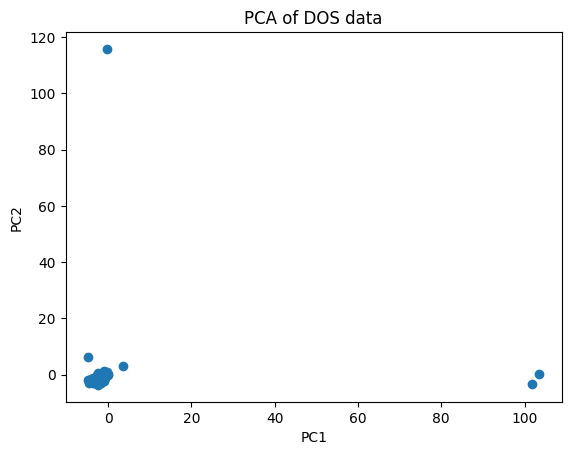

In [8]:
# Visualise the Principal Components 
plt.figure()
plt.scatter(principal_components[:, 0], principal_components[:, 1])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of DOS data')
plt.show()

## 2. Explained Variance Ratio
how much of the original data’s variance is captured by each principal component. It helps in understanding the importance of each component

Total variance explained by each principal component (PC): Indicate how much of the variation in your dataset is captured by each PC. This helps justify how many components should be kept for downstream analysis.
- USE BAR GRAPH

Cumulative variance: If, for example, the first few PCs explain 95% of the variance, it shows that you can reduce the dimensionality significantly without losing much information.
- USE STEP GRAPH

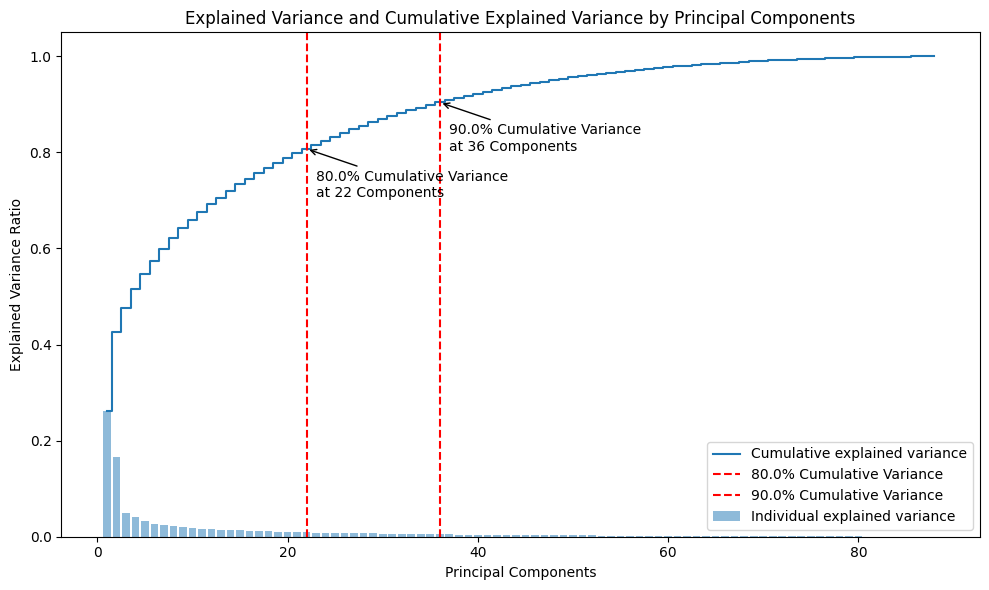

In [9]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
# print(f"The explained variance is {explained_variance}")

# Plotting the explained variance and cumulative variance
plt.figure(figsize=(10,6))

# Plotting explained variance
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.5, align='center', label='Individual explained variance')

# Plotting cumulative variance
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Cumulative explained variance')

# Find the number of components needed for 90% cumulative variance
thresholds = [0.80, 0.90]

for threshold in thresholds:
    num_components_threshold = np.argmax(cumulative_variance >= threshold) + 1
    # Adding a vertical line at the 90% cumulative variance point
    plt.axvline(x=num_components_threshold, color='r', linestyle='--', label=f'{threshold*100}% Cumulative Variance')

    # Annotating the line
    plt.annotate(f'{threshold*100}% Cumulative Variance\nat {num_components_threshold} Components',
                xy=(num_components_threshold, cumulative_variance[num_components_threshold - 1]),
                xytext=(num_components_threshold + 1, cumulative_variance[num_components_threshold - 1] - 0.1),
                arrowprops=dict(facecolor='black', arrowstyle='->'),
                fontsize=10)


# Adding labels and titles
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance and Cumulative Explained Variance by Principal Components')
plt.legend(loc='best')
plt.tight_layout()

# Show the plot
plt.show()

In [10]:
# Step 4: Find the number of components needed for 90% cumulative variance
threshold_90 = 0.90
num_components_90 = np.argmax(cumulative_variance >= threshold_90) + 1

# Step 5: Find the number of components needed for 80% cumulative variance
threshold_80 = 0.80
num_components_80 = np.argmax(cumulative_variance >= threshold_80) + 1

# Create a DataFrame to show cumulative variance between 0.80 and 0.90 thresholds
cumulative_variance_df = pd.DataFrame({
    'Component': range(num_components_80, num_components_90 + 1),
    'Cumulative Variance': cumulative_variance[num_components_80 - 1:num_components_90]
})

# Display the DataFrame
cumulative_variance_df

,Component,Cumulative Variance
0,22,0.807305
1,23,0.816059
2,24,0.824330
3,25,0.832436
4,26,0.840362
5,27,0.848056
6,28,0.855663
7,29,0.862726
8,30,0.869314
9,31,0.875723


In [11]:
# Create a DataFrame to show all principal components and their cumulative variance
all_components_df = pd.DataFrame({
    'Principal Component': range(1, len(explained_variance) + 1),
    'Explained Variance': explained_variance,
    'Cumulative Variance': cumulative_variance
})

# Save the DataFrame to a text file
all_components_df.to_csv('components_variance.txt', sep='\t', index=False)

# Limit to the first 100 components
num_components_to_display = min(40, len(explained_variance))
components_df = pd.DataFrame({
    'Principal Component': range(1, num_components_to_display + 1),
    'Explained Variance': explained_variance[:num_components_to_display],
    'Cumulative Variance': cumulative_variance[:num_components_to_display]
})

# Display the DataFrame components_df

## 3. Principal Components Interpretation

**Loading Scores**
- See which features (DOS data columns contribute most to each PC)
- Provides insight into which orbitals or energy ranges are influencing the variance

In [12]:
# Loading Scores (principal component coefficients)
# The components_ attribute contains the loading scores
loading_scores = pd.DataFrame(pca.components_.T, 
                              index=dos_data.columns, 
                              columns=[f'PC{i+1}' for i in range(len(pca.components_))])

loading_scores.to_csv('loading_scores.txt', sep='\t', index=False)

"""
# Display the loading scores for each PC
print ("Loading Scores (Principal Component Coefficients):")
loading_scores
"""

Loading Scores (Principal Component Coefficients):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC79,PC80,PC81,PC82,PC83,PC84,PC85,PC86,PC87,PC88
1,4.967299e-17,6.128110e-17,-2.399963e-17,-1.541939e-17,3.334816e-17,-2.459640e-17,7.074939e-18,-3.307061e-17,7.626009e-18,-3.204464e-17,...,-6.853450e-17,4.468064e-17,-4.922464e-17,-6.067902e-17,1.982020e-17,5.351163e-17,1.401442e-17,-2.358486e-16,9.674056e-17,0.163523
2,2.267937e-17,2.694102e-17,-6.043821e-17,-3.915122e-18,-4.313741e-17,-5.725074e-17,2.438127e-17,-2.297749e-17,1.134261e-17,-2.457536e-17,...,1.776410e-16,-8.113932e-17,1.209367e-16,-5.509189e-18,7.344998e-18,-4.912486e-17,-1.026656e-16,-5.896909e-17,-2.259276e-17,0.111796
3,3.502554e-17,5.783818e-17,-4.382350e-17,-4.191394e-18,1.027311e-17,-1.064987e-17,-1.848447e-17,-5.039838e-17,1.054585e-16,1.579189e-17,...,-1.648019e-16,-7.544702e-17,-1.214731e-16,9.481855e-19,-5.242269e-17,2.975279e-16,6.611502e-17,1.395107e-16,-2.913183e-16,0.043509
4,3.304339e-17,1.601664e-19,-8.712519e-18,1.152943e-17,2.882992e-18,-3.425448e-17,1.635599e-17,-1.127816e-16,-6.393938e-17,-4.716755e-17,...,-7.420149e-17,-1.369338e-16,1.113604e-16,1.130268e-16,2.730224e-17,-9.058218e-17,-9.760486e-17,-1.587096e-16,6.153772e-17,0.001462
5,3.773006e-18,3.618118e-17,-8.089509e-17,-2.999792e-17,-2.589220e-18,-3.984652e-17,3.083907e-17,-1.309352e-17,1.344205e-16,-1.108207e-17,...,3.375241e-17,4.451896e-17,-5.523940e-17,2.141126e-17,4.984924e-17,1.208966e-16,-1.408889e-17,-1.683480e-16,-2.010059e-17,0.241601
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,0.000000
997,0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,0.000000
998,0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,0.000000
999,0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,0.000000


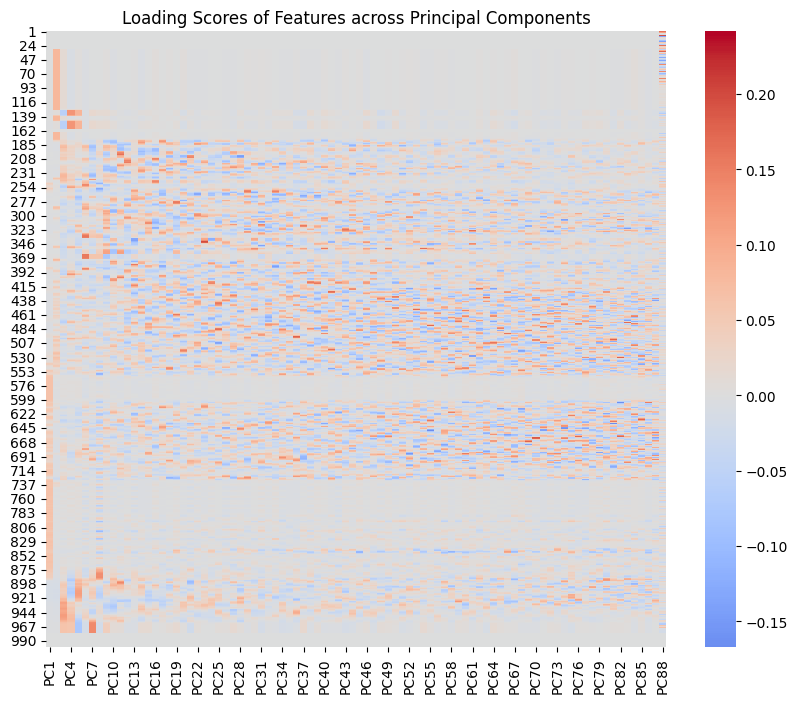

In [13]:
# Visualizing all loading scores using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(loading_scores, cmap='coolwarm', center=0)
plt.title('Loading Scores of Features across Principal Components')
plt.show()